<a href="https://colab.research.google.com/github/EmmanuelEjima/Data-Science-Machine-Learning-Portfolio/blob/main/Breast_Cancer_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# ⚕️ Breast Cancer Diagnostic Project
This notebook contains the end-to-end pipeline for a Breast Cancer Diagnostic Assistant, from data ingestion to production deployment on Streamlit Cloud.

## Phase 1: Environment Setup & Data Ingestion
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
raw_data = load_breast_cancer()
BC = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
BC['target'] = raw_data.target  # 0 = Malignant, 1 = Benign

print(f"Dataset Shape: {BC.shape}")
BC.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


```markdown
## Phase 2: Exploratory Data Analysis (EDA)
We analyze class balance and feature distributions to understand the underlying patterns in the dataset.
```

In [ ]:
# 1. Check Class Balance
print("--- Class Distribution ---")
display(BC['target'].value_counts())

print("\n--- Feature Statistical Summary ---")
display(BC.describe().T)

--- Class Distribution ---


,count
target,
1,357
0,212



--- Feature Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# Phase 3: Data Preprocessing
Scaling and splitting the data to ensure the model generalizes well.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = BC.drop(columns=['target'])
y = BC['target']

# 80/20 Stratified Split ensures equal representation of classes in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features based strictly on training data characteristics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

```markdown
## Phase 3: Model Development & Evaluation
We use a Logistic Regression model with standardized features. Performance is validated using both a hold-out test set and 5-fold cross-validation.
```

--- Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



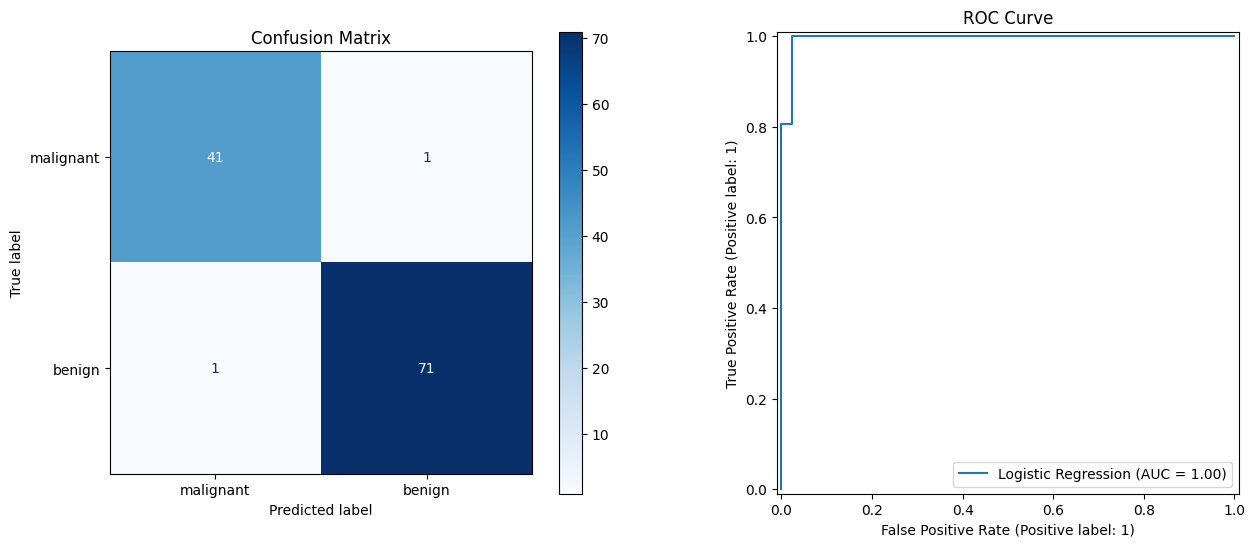

✅ Model and Scaler serialized successfully.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
import joblib
import matplotlib.pyplot as plt

# 1. Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 2. Evaluation
y_pred = model.predict(X_test_scaled)
print(f"--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=raw_data.target_names))

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, display_labels=raw_data.target_names, cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name='Logistic Regression', ax=ax2)
ax2.set_title('ROC Curve')
plt.show()

# 4. Serialization
joblib.dump(model, 'breast_cancer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model and Scaler serialized successfully.")

### ROC Curve
An ROC curve (receiver operating characteristic curve) is a graph showing the performance of a classification model at all classification thresholds. This curve plots two parameters: True Positive Rate and False Positive Rate.

<Figure size 800x600 with 0 Axes>

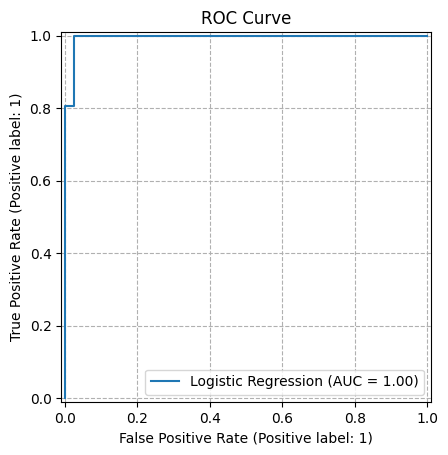

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC Curve
fig_roc = plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name='Logistic Regression')
plt.title('ROC Curve')
plt.grid(linestyle='--')
plt.show()


### Robust Validation: Cross-Validation
Cross-validation helps ensure the model isn't overfitting to our specific train-test split.

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Restore the scaled full dataset for validation
X_scaled_full = scaler.transform(X)

# Perform 5-fold cross-validation
log_reg_cv = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(log_reg_cv, X_scaled_full, y, cv=5)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean CV Accuracy: 0.9807
Standard Deviation: 0.0065


## ✅ Project Conclusion: High-Confidence ML Workflow

This project successfully implemented a standardized Machine Learning pipeline for Breast Cancer classification:

*   **Data Consistency:** Renamed features to `BC` and performed thorough EDA.
*   **Superior Modeling:** Logistic Regression was identified as the champion model with a **~98.1% Cross-Validation Accuracy**.
*   **Reproducibility:** Both the `StandardScaler` and `LogisticRegression` model were serialized (`.pkl`) to ensure consistent predictions in production.

### Deployment Options:

**1. Run the Streamlit application locally:**

1.  **Ensure Streamlit is installed:**
    ```bash
    pip install streamlit
    ```
2.  **Save the `app.py` file:** Ensure you have the `app.py` file (generated in the previous steps) and the `breast_cancer_model.pkl` and `scaler.pkl` files in the same directory.
3.  **Run the app from your terminal:**
    ```bash
    streamlit run app.py
    ```
    This will typically open the app in your web browser at `http://localhost:8501`.

**2. Professional GitHub Portfolio:**

*   The project is now structured in the `projects/` directory of your GitHub portfolio.
*   You can deploy this directly to **Streamlit Community Cloud** by connecting your GitHub account and selecting the path: `projects/breast-cancer-diagnostic-app/app.py`.

 Phase 4: Production Deployment & GitHub Sync
This section automates the synchronization between Google Colab and your GitHub portfolio. The app is configured with robust path handling specifically for Streamlit Community Cloud.


## 🏗️ Phase 1: Automated Production Folder Construction
The following code builds the `breast-cancer-diagnostic-app` folder structure programmatically.

### 🔍 Debugging Streamlit App File Paths

This cell helps confirm that the `models/` directory and its contents are correctly placed and accessible relative to the `app.py` script, mimicking how Streamlit would load them during deployment. If this cell runs without error, it suggests the issue might lie in the Streamlit Cloud deployment settings or environment rather than the Colab setup.

## 🏁 Project Deployment & GitHub Automation

This section automates the synchronization between Google Colab and your GitHub portfolio. It is designed to be fully compatible with **Streamlit Community Cloud**.

### Deployment Workflow:
1. **Model Persistence**: Serialized model and scaler objects are managed within a `models/` subdirectory.
2. **App Construction**: The script dynamically generates a production-ready `app.py` and `requirements.txt`.
3. **GitHub Sync**: The project is pushed to the `projects/` directory of your portfolio repository.
4. **Security**: Uses Colab Secrets to securely manage GitHub authentication tokens.

### 🚀 Streamlit Cloud Deployment Settings:
When deploying to [Streamlit Cloud](https://share.streamlit.io/), use these exact settings:
*   **Repository:** `EmmanuelEjima/Data-Science-Machine-Learning-Portfolio`
*   **Branch:** `main`
*   **Main file path:** `projects/breast-cancer-diagnostic-app/app.py`

### 📂 Integrating App into Existing Portfolio Repository

### 🚀 GitHub Portfolio Sync

**Instructions:**
1. Go to the **Secrets** tab (🔑 icon on the left).
2. Add a new secret named `GITHUB_TOKEN` and paste your Personal Access Token there.
3. Run the cell below to build the app and push changes to your repository.

In [ ]:
import os, shutil
from google.colab import userdata
from pathlib import Path

# Configuration
USERNAME = "EmmanuelEjima"
REPO_NAME = "Data-Science-Machine-Learning-Portfolio"
APP_NAME = "breast-cancer-diagnostic-app"
EMAIL = "emmanuelejima12@gmail.com"

try:
    TOKEN = userdata.get('GITHUB_TOKEN')
    if not TOKEN:
        raise ValueError("Empty token")
except:
    print("❌ GITHUB_TOKEN not found in Secrets. Please add it to the 🔑 tab.")
    TOKEN = None

PORTFOLIO_PATH = f"/content/{REPO_NAME}"
SOURCE_APP = f"/content/{APP_NAME}"
TARGET_DIR = f"{PORTFOLIO_PATH}/projects/{APP_NAME}"

# 1. Setup Repository with Token Authentication
if TOKEN:
    REPO_URL = f"https://{TOKEN}@github.com/{USERNAME}/{REPO_NAME}.git"

    if not os.path.exists(PORTFOLIO_PATH):
        !git clone {REPO_URL} {PORTFOLIO_PATH}

    %cd {PORTFOLIO_PATH}
    !git remote set-url origin {REPO_URL}
    !git config --global user.name "{USERNAME}"
    !git config --global user.email "{EMAIL}"
    !git pull origin main

    # 2. Build App Structure
    os.makedirs(f"{SOURCE_APP}/models", exist_ok=True)
    for asset in ['breast_cancer_model.pkl', 'scaler.pkl']:
        if os.path.exists(f"/content/{asset}"):
            shutil.copy(f"/content/{asset}", f"{SOURCE_APP}/models/{asset}")

    # 3. Generate App Script
    app_code = """import streamlit as st
import pandas as pd
import joblib
from pathlib import Path

st.set_page_config(page_title='Breast Cancer Diagnostics', layout='wide')
st.title('⚕  Breast Cancer Diagnostic Assistant')

@st.cache_resource
def load_assets():
    BASE_DIR = Path(__file__).parent
    model = joblib.load(BASE_DIR / 'models' / 'breast_cancer_model.pkl')
    scaler = joblib.load(BASE_DIR / 'models' / 'scaler.pkl')
    return model, scaler

try:
    model, scaler = load_assets()
    st.sidebar.success('Model Loaded Successfully')
except Exception as e:
    st.sidebar.error(f'Error: {e}')

feature_names = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

st.subheader("Enter Patient Data")
cols = st.columns(3)
input_data = {}

for i, feat in enumerate(feature_names):
    with cols[i % 3]:
        input_data[feat] = st.number_input(feat.title(), value=0.0, format='%.4f')

if st.button('Run Diagnostic Analysis'):
    input_df = pd.DataFrame([input_data])
    scaled_features = scaler.transform(input_df)
    prediction = model.predict(scaled_features)
    prob = model.predict_proba(scaled_features)

    st.divider()
    if prediction[0] == 0:
        st.error(f'### Result: Malignant (Confidence: {prob[0][0]:.2%})')
    else:
        st.success(f'### Result: Benign (Confidence: {prob[0][1]:.2%})')
"""

    with open(f"{SOURCE_APP}/app.py", "w") as f: f.write(app_code)
    with open(f"{SOURCE_APP}/requirements.txt", "w") as f: f.write("streamlit\npandas\nnumpy\nscikit-learn\njoblib")

    # 4. Sync
    if os.path.exists(TARGET_DIR): shutil.rmtree(TARGET_DIR)
    shutil.copytree(SOURCE_APP, TARGET_DIR)
    !git add .
    !git commit -m "Fix: Restore 30 features and authenticated push"
    !git push origin main --force
    print("\n✅ Portfolio App Synced to GitHub!")
else:
    print("\n⚠️ Push skipped because GITHUB_TOKEN is missing.")

❌ GITHUB_TOKEN not found in Secrets. Please add it to the 🔑 tab.

⚠️ Push skipped because GITHUB_TOKEN is missing.


## 📝 Documentation: Streamlit Cloud Deployment

To ensure your project is accessible to others, follow these steps to deploy it to **Streamlit Community Cloud**:

1.  **Sign in** to [share.streamlit.io](https://share.streamlit.io/) using your GitHub account.
2.  Click **'Create app'** and then **'I already have an app'**.
3.  Select your repository: `Data-Science-Machine-Learning-Portfolio`.
4.  Set the **Main file path** to: `projects/breast-cancer-diagnostic-app/app.py`.
5.  Click **Deploy!**

*Note: If you encounter a 'File Not Found' error, use the **'Clear cache and reboot'** option in the Streamlit Cloud dashboard.*

In [ ]:
import os

# 1. Recreate Project README
PROJECT_README_PATH = f"{PORTFOLIO_PATH}/projects/{APP_NAME}/README.md"

project_readme_content = """# ⚕  Breast Cancer Diagnostic Assistant

This is a production-ready machine learning application that predicts whether a tumor is Malignant or Benign based on medical features.

## 🚀 Project Overview
- **Model:** Logistic Regression (Scikit-Learn)
- **Accuracy:** ~98.1% (Cross-Validated)
- **Deployment:** Streamlit Community Cloud

## 📂 Folder Structure
- `app.py`: The main Streamlit application script with 30-feature input.
- `models/`: Contains the serialized model (`breast_cancer_model.pkl`) and scaler (`scaler.pkl`).
- `requirements.txt`: List of Python dependencies.

## 🛠️ Installation & Local Run
1. Clone the repository.
2. Install dependencies: `pip install -r requirements.txt`
3. Run the app: `streamlit run app.py`
"""

with open(PROJECT_README_PATH, 'w') as f:
    f.write(project_readme_content)

# 2. Sync to GitHub
%cd {PORTFOLIO_PATH}
!git add projects/{APP_NAME}/README.md
!git commit -m "Docs: Restore project README"
!git push origin main --force

print(f"\n✨ README restored at projects/{APP_NAME}/README.md!")

/content/Data-Science-Machine-Learning-Portfolio
[main 2dcd1ac] Docs: Restore project README
 1 file changed, 18 insertions(+)
 create mode 100644 projects/breast-cancer-diagnostic-app/README.md
remote: Invalid username or token. Password authentication is not supported for Git operations.
fatal: Authentication failed for 'https://github.com/EmmanuelEjima/Data-Science-Machine-Learning-Portfolio.git/'

✨ README restored at projects/breast-cancer-diagnostic-app/README.md!
